# Task 1 (Level 2): Predicting House Prices with Linear Regression

**Track:** Data Analytics - Level 2
**Objective:** Build and evaluate a linear regression model that predicts house prices based on features such as area, location, number of rooms, and age. Develop end-to-end skills from data cleaning through to model interpretation.

**Tech Stack:** Python, pandas, scikit-learn, matplotlib, seaborn, Jupyter Notebook

## 1. Load Dataset & Initial EDA

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.impute import SimpleImputer

# Set style
plt.style.use('seaborn-v0_8')
sns.set_palette('husl')

# Load dataset
df = pd.read_csv('house_prices.csv')
print(f'Dataset Shape: {df.shape}')
print(f'\nFirst 5 rows:')
display(df.head())
print(f'\nColumn Names ({len(df.columns)}): {list(df.columns)}')
print(f'\nData Types:')
print(df.dtypes)

Dataset Shape: (2000, 34)

First 5 rows:


,id,sale_price,lot_area,overall_qual,overall_cond,year_built,year_remod_add,mas_vnr_area,bsmt_fin_sf1,bsmt_fin_sf2,...,bldg_type,house_style,roof_style,exterior_1st,foundation,heating,central_air,electrical,sale_type,sale_condition
0,1,356055,9532,8,9,2010,2018,47.0,1167,12,...,1Fam,2Story,Hip,Wd Sdng,PConc,GasW,Y,SBrkr,WD,Normal
1,2,238251,12428,3,10,1916,1979,28.0,1179,31,...,1Fam,1Story,Gable,BrkFace,CBlock,GasA,Y,SBrkr,New,Normal
2,3,414542,8989,10,2,1916,1957,27.0,142,46,...,1Fam,1.5Fin,Gable,MetalSd,PConc,GasA,N,SBrkr,Oth,Normal
3,4,420433,11453,8,6,2010,1987,37.0,7,20,...,1Fam,1Story,Gable,MetalSd,CBlock,GasA,Y,SBrkr,WD,Normal
4,5,337817,5183,8,3,1914,2010,22.0,389,17,...,2fmCon,1Story,Gable,VinylSd,PConc,GasA,Y,NaN,WD,Normal



Column Names (34): ['id', 'sale_price', 'lot_area', 'overall_qual', 'overall_cond', 'year_built', 'year_remod_add', 'mas_vnr_area', 'bsmt_fin_sf1', 'bsmt_fin_sf2', 'bsmt_unf_sf', 'total_bsmt_sf', 'first_flr_sf', 'second_flr_sf', 'gr_liv_area', 'bedroom_abvgr', 'kitchen_abvgr', 'tot_rms_abvgrd', 'fireplaces', 'garage_cars', 'garage_area', 'wood_deck_sf', 'open_porch_sf', 'neighborhood', 'bldg_type', 'house_style', 'roof_style', 'exterior_1st', 'foundation', 'heating', 'central_air', 'electrical', 'sale_type', 'sale_condition']

Data Types:
id                  int64
sale_price          int64
lot_area            int64
overall_qual        int64
overall_cond        int64
year_built          int64
year_remod_add      int64
mas_vnr_area      float64
bsmt_fin_sf1        int64
bsmt_fin_sf2        int64
bsmt_unf_sf         int64
total_bsmt_sf       int64
first_flr_sf        int64
second_flr_sf       int64
gr_liv_area         int64
bedroom_abvgr       int64
kitchen_abvgr       int64
tot_rms_abvg

## 2. Null Check & Descriptive Statistics

=== NULL VALUES ===


,Null Count,Null %
mas_vnr_area,97,4.85
garage_area,98,4.90
wood_deck_sf,100,5.00
open_porch_sf,94,4.70
electrical,154,7.70



=== TARGET VARIABLE (sale_price) STATISTICS ===
count      2000.000000
mean     315566.609000
std       60603.885889
min      125896.000000
25%      269871.250000
50%      313242.500000
75%      356892.750000
max      630337.000000
Name: sale_price, dtype: float64


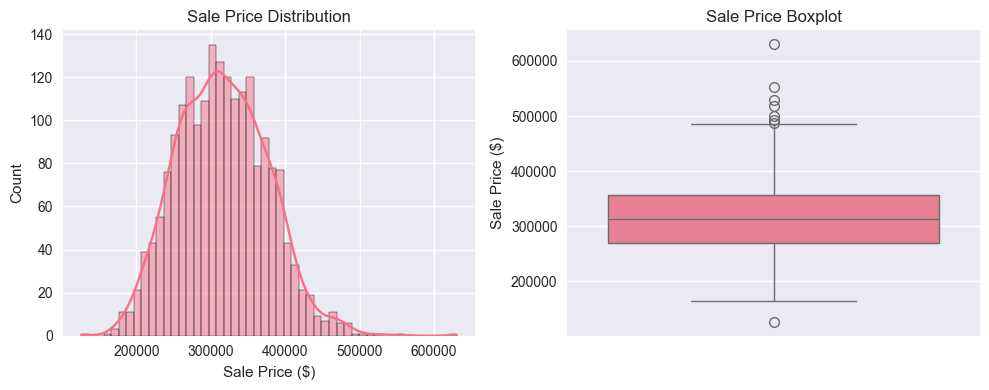

In [2]:
# Null value check
print('=== NULL VALUES ===')
null_report = pd.DataFrame({
    'Null Count': df.isnull().sum(),
    'Null %': (df.isnull().sum() / len(df) * 100).round(2)
})
display(null_report[null_report['Null Count'] > 0])

# Descriptive statistics for target variable
print('\n=== TARGET VARIABLE (sale_price) STATISTICS ===')
print(df['sale_price'].describe())

# Distribution plot for target
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
sns.histplot(df['sale_price'], kde=True, bins=50)
plt.title('Sale Price Distribution')
plt.xlabel('Sale Price ($)')

plt.subplot(1, 2, 2)
sns.boxplot(y=df['sale_price'])
plt.title('Sale Price Boxplot')
plt.ylabel('Sale Price ($)')

plt.tight_layout()
plt.show()

## 3. Feature Selection Discussion

**Likely Predictors for House Price:**

**High Impact (Strong Theoretical Correlation):**
- gr_liv_area (Above ground living area) - Direct measure of usable space
- total_bsmt_sf (Total basement area) - Additional living/storage space
- overall_qual (Overall material and finish quality) - Quality directly affects value
- garage_cars / garage_area - Garage capacity is highly valued
- year_built / year_remod_add - Age and renovation status
- neighborhood - Location is paramount in real estate

**Medium Impact:**
- first_flr_sf, second_flr_sf - Floor-specific area
- bedroom_abvgr, tot_rms_abvgrd - Room counts
- fireplaces - Premium feature
- lot_area - Land size
- central_air - Modern comfort feature

**Lower Impact / Redundant:**
- id - No predictive value
- bsmt_fin_sf1, bsmt_fin_sf2, bsmt_unf_sf - Components of total_bsmt_sf
- first_flr_sf, second_flr_sf - Components of gr_liv_area
- roof_style, heating - Less variation, modern standards

**Selected Features for Modeling:** We will use a focused set avoiding multicollinearity.

## 4. Handle Missing Values & Encode Categorical Features

In [3]:
# Prepare features and target
target = 'sale_price'
X = df.drop(columns=[target, 'id'])
y = df[target]

# Identify column types
numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()

print(f'Numeric features ({len(numeric_cols)}): {numeric_cols}')
print(f'Categorical features ({len(categorical_cols)}): {categorical_cols}')

# Check missing in numeric
print('\nNumeric missing:')
print(X[numeric_cols].isnull().sum()[X[numeric_cols].isnull().sum() > 0])

print('\nCategorical missing:')
print(X[categorical_cols].isnull().sum()[X[categorical_cols].isnull().sum() > 0])

Numeric features (21): ['lot_area', 'overall_qual', 'overall_cond', 'year_built', 'year_remod_add', 'mas_vnr_area', 'bsmt_fin_sf1', 'bsmt_fin_sf2', 'bsmt_unf_sf', 'total_bsmt_sf', 'first_flr_sf', 'second_flr_sf', 'gr_liv_area', 'bedroom_abvgr', 'kitchen_abvgr', 'tot_rms_abvgrd', 'fireplaces', 'garage_cars', 'garage_area', 'wood_deck_sf', 'open_porch_sf']
Categorical features (11): ['neighborhood', 'bldg_type', 'house_style', 'roof_style', 'exterior_1st', 'foundation', 'heating', 'central_air', 'electrical', 'sale_type', 'sale_condition']

Numeric missing:
mas_vnr_area      97
garage_area       98
wood_deck_sf     100
open_porch_sf     94
dtype: int64

Categorical missing:
electrical    154
dtype: int64


C:\Users\ASUS\AppData\Local\Temp\ipykernel_8860\2986548758.py:8: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X.select_dtypes(include=['object']).columns.tolist()


In [4]:
# Create preprocessing pipelines
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_cols),
        ('cat', categorical_transformer, categorical_cols)
    ]
)

# Train/test split first
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f'Train size: {X_train.shape[0]}, Test size: {X_test.shape[0]}')

# Fit preprocessor on training data only
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# Get feature names after one-hot encoding
cat_feature_names = preprocessor.named_transformers_['cat'].named_steps['onehot'].get_feature_names_out(categorical_cols)
feature_names = numeric_cols + list(cat_feature_names)

print(f'Processed feature shape: {X_train_processed.shape}')
print(f'Number of features after encoding: {len(feature_names)}')

Train size: 1600, Test size: 400
Processed feature shape: (1600, 88)
Number of features after encoding: 88


## 5. Correlation Heatmap (Numeric Features Only)

C:\Users\ASUS\AppData\Local\Temp\ipykernel_8860\1665049244.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_corr.values, y=top_corr.index, palette='RdBu_r')


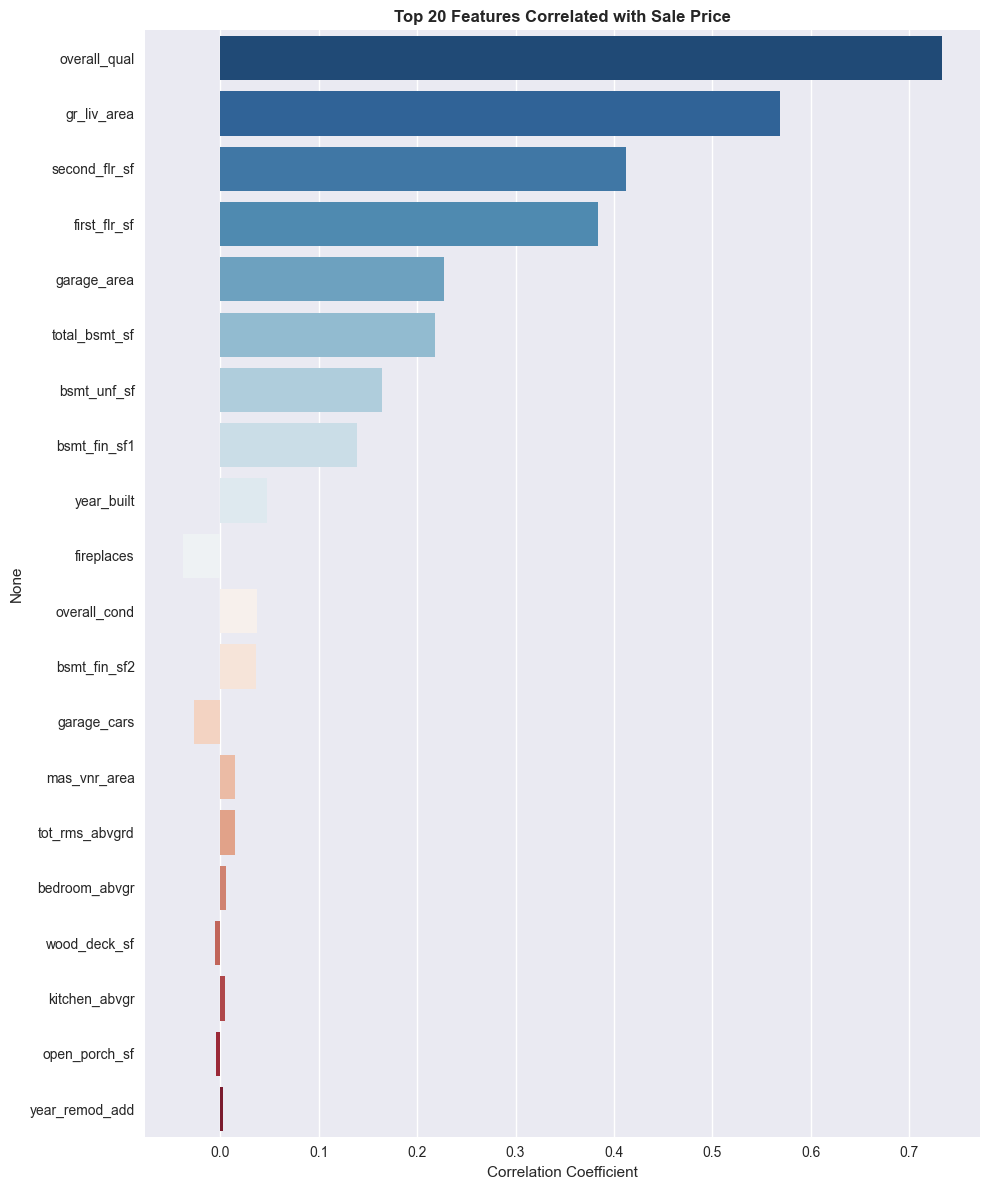

=== TOP 20 CORRELATIONS WITH SALE_PRICE ===
overall_qual      0.733197
gr_liv_area       0.568829
second_flr_sf     0.412432
first_flr_sf      0.383293
garage_area       0.227672
total_bsmt_sf     0.218103
bsmt_unf_sf       0.164470
bsmt_fin_sf1      0.139060
year_built        0.047525
fireplaces       -0.038256
overall_cond      0.037792
bsmt_fin_sf2      0.036218
garage_cars      -0.026577
mas_vnr_area      0.015415
tot_rms_abvgrd    0.014688
bedroom_abvgr     0.005480
wood_deck_sf     -0.005238
kitchen_abvgr     0.004515
open_porch_sf    -0.003880
year_remod_add    0.002845


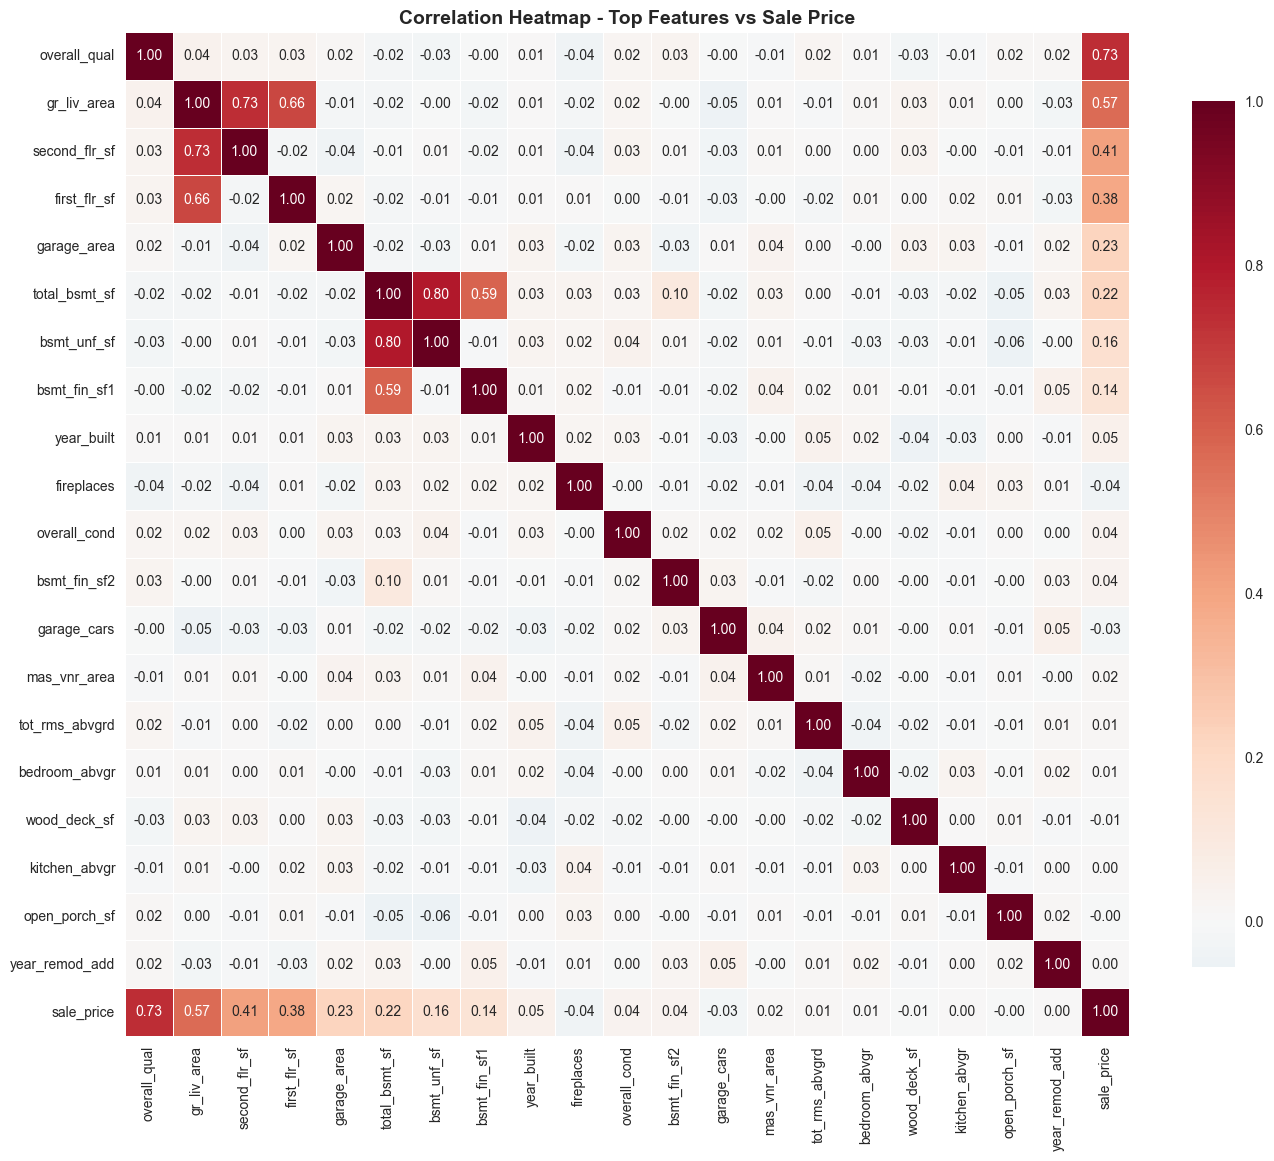

In [5]:
# Correlation with target (using original numeric features)
numeric_df = df[numeric_cols + [target]].copy()
# Fill missing for correlation
numeric_df = numeric_df.fillna(numeric_df.median())

corr_matrix = numeric_df.corr()
price_corr = corr_matrix[target].drop(target).sort_values(key=abs, ascending=False)

plt.figure(figsize=(10, 12))
# Top 20 correlated features
top_corr = price_corr.head(20)
sns.barplot(x=top_corr.values, y=top_corr.index, palette='RdBu_r')
plt.title('Top 20 Features Correlated with Sale Price', fontweight='bold')
plt.xlabel('Correlation Coefficient')
plt.tight_layout()
plt.show()

print('=== TOP 20 CORRELATIONS WITH SALE_PRICE ===')
print(top_corr.to_string())

# Full correlation heatmap (top correlated features)
top_features = list(top_corr.index) + [target]
plt.figure(figsize=(14, 12))
sns.heatmap(numeric_df[top_features].corr(), annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Correlation Heatmap - Top Features vs Sale Price', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 6. Train Linear Regression Model

In [6]:
# Train Linear Regression
lr = LinearRegression()
lr.fit(X_train_processed, y_train)

# Predictions
y_pred_train = lr.predict(X_train_processed)
y_pred_test = lr.predict(X_test_processed)

# Evaluation metrics
def evaluate_model(y_true, y_pred, prefix=''):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return {
        prefix + 'MSE': mse,
        prefix + 'RMSE': rmse,
        prefix + 'MAE': mae,
        prefix + 'R2': r2
    }

train_metrics = evaluate_model(y_train, y_pred_train, 'Train_')
test_metrics = evaluate_model(y_test, y_pred_test, 'Test_')

print('=== LINEAR REGRESSION RESULTS ===')
for k, v in {**train_metrics, **test_metrics}.items():
    print('{}: {:,.4f}'.format(k, v))

=== LINEAR REGRESSION RESULTS ===
Train_MSE: 216,627,362.9581
Train_RMSE: 14,718.2663
Train_MAE: 11,703.4944
Train_R2: 0.9406
Test_MSE: 235,036,461.8267
Test_RMSE: 15,330.8989
Test_MAE: 12,311.5500
Test_R2: 0.9374


## 7. Actual vs Predicted Prices (Scatter Plot)

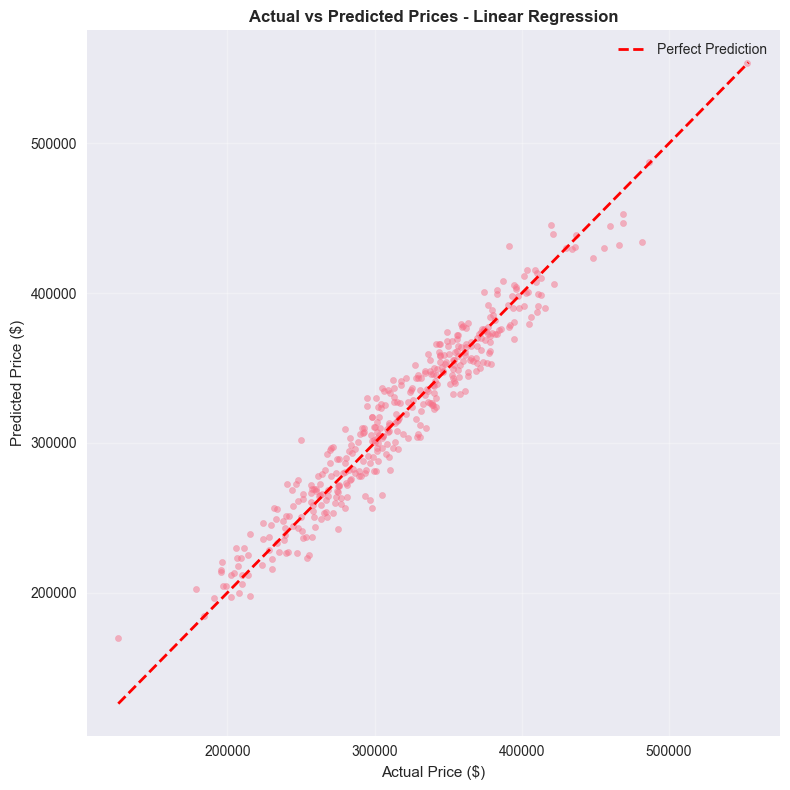

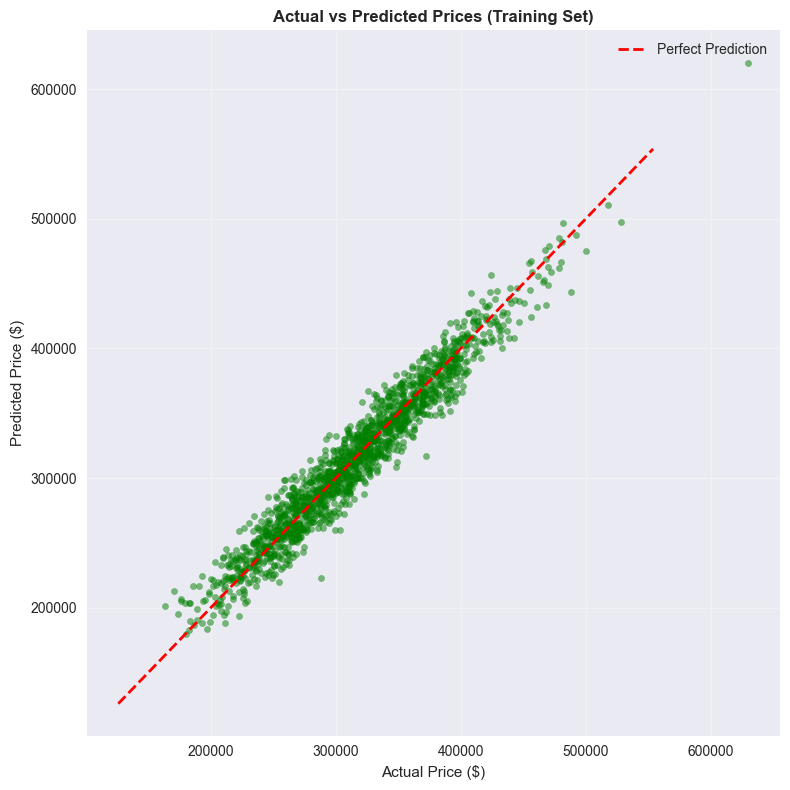

In [7]:
plt.figure(figsize=(8, 8))
plt.scatter(y_test, y_pred_test, alpha=0.5, s=20)
# Diagonal line
min_val = min(y_test.min(), y_pred_test.min())
max_val = max(y_test.max(), y_pred_test.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect Prediction')
plt.xlabel('Actual Price ($)')
plt.ylabel('Predicted Price ($)')
plt.title('Actual vs Predicted Prices - Linear Regression', fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Also show train for comparison
plt.figure(figsize=(8, 8))
plt.scatter(y_train, y_pred_train, alpha=0.5, s=20, color='green')
plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect Prediction')
plt.xlabel('Actual Price ($)')
plt.ylabel('Predicted Price ($)')
plt.title('Actual vs Predicted Prices (Training Set)', fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 8. Residual Analysis

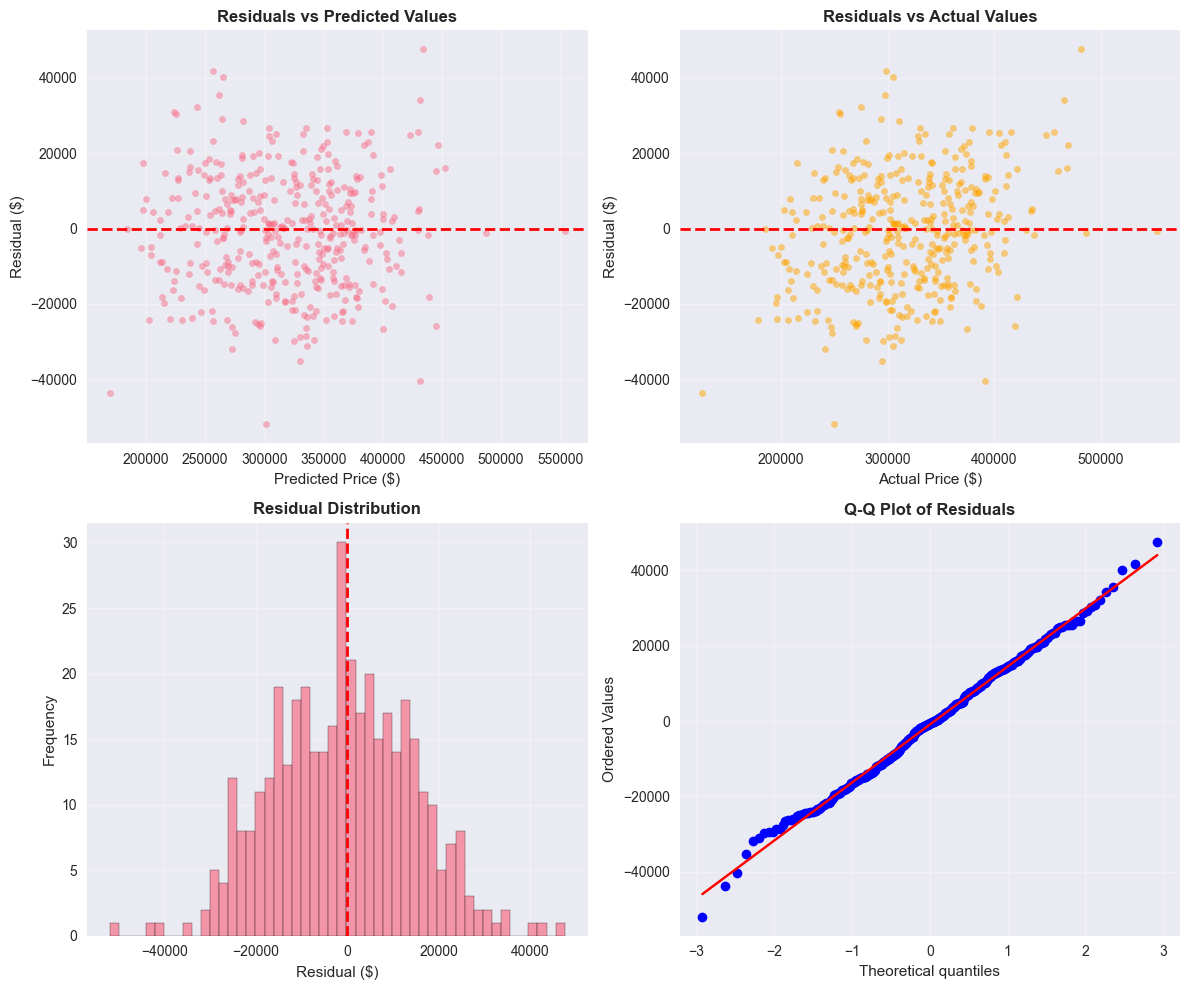

=== RESIDUAL STATISTICS ===
Mean: -941.71
Std: 15321.11
Skewness: 0.0338
Kurtosis: -0.0500


In [8]:
# Calculate residuals
residuals = y_test - y_pred_test

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Residuals vs Predicted
axes[0, 0].scatter(y_pred_test, residuals, alpha=0.5, s=20)
axes[0, 0].axhline(y=0, color='r', linestyle='--', lw=2)
axes[0, 0].set_xlabel('Predicted Price ($)')
axes[0, 0].set_ylabel('Residual ($)')
axes[0, 0].set_title('Residuals vs Predicted Values', fontweight='bold')
axes[0, 0].grid(True, alpha=0.3)

# Residuals vs Actual
axes[0, 1].scatter(y_test, residuals, alpha=0.5, s=20, color='orange')
axes[0, 1].axhline(y=0, color='r', linestyle='--', lw=2)
axes[0, 1].set_xlabel('Actual Price ($)')
axes[0, 1].set_ylabel('Residual ($)')
axes[0, 1].set_title('Residuals vs Actual Values', fontweight='bold')
axes[0, 1].grid(True, alpha=0.3)

# Histogram of residuals
axes[1, 0].hist(residuals, bins=50, edgecolor='black', alpha=0.7)
axes[1, 0].axvline(x=0, color='r', linestyle='--', lw=2)
axes[1, 0].set_xlabel('Residual ($)')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title('Residual Distribution', fontweight='bold')
axes[1, 0].grid(True, alpha=0.3)

# Q-Q plot
from scipy import stats
stats.probplot(residuals, dist='norm', plot=axes[1, 1])
axes[1, 1].set_title('Q-Q Plot of Residuals', fontweight='bold')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Residual statistics
print('=== RESIDUAL STATISTICS ===')
print('Mean: {:.2f}'.format(residuals.mean()))
print('Std: {:.2f}'.format(residuals.std()))
print('Skewness: {:.4f}'.format(residuals.skew()))
print('Kurtosis: {:.4f}'.format(residuals.kurtosis()))

## 9. Coefficient Analysis

=== TOP 20 FEATURE COEFFICIENTS (by absolute value) ===


,Feature,Coefficient
1,overall_qual,43007.907288
12,gr_liv_area,16582.254622
18,garage_area,13522.213819
11,second_flr_sf,12222.148113
10,first_flr_sf,10672.819870
65,heating_OthW,9190.429731
78,sale_type_ConLw,-8833.190460
43,roof_style_Flat,-8090.087241
9,total_bsmt_sf,7435.024928
77,sale_type_ConLI,5459.758919


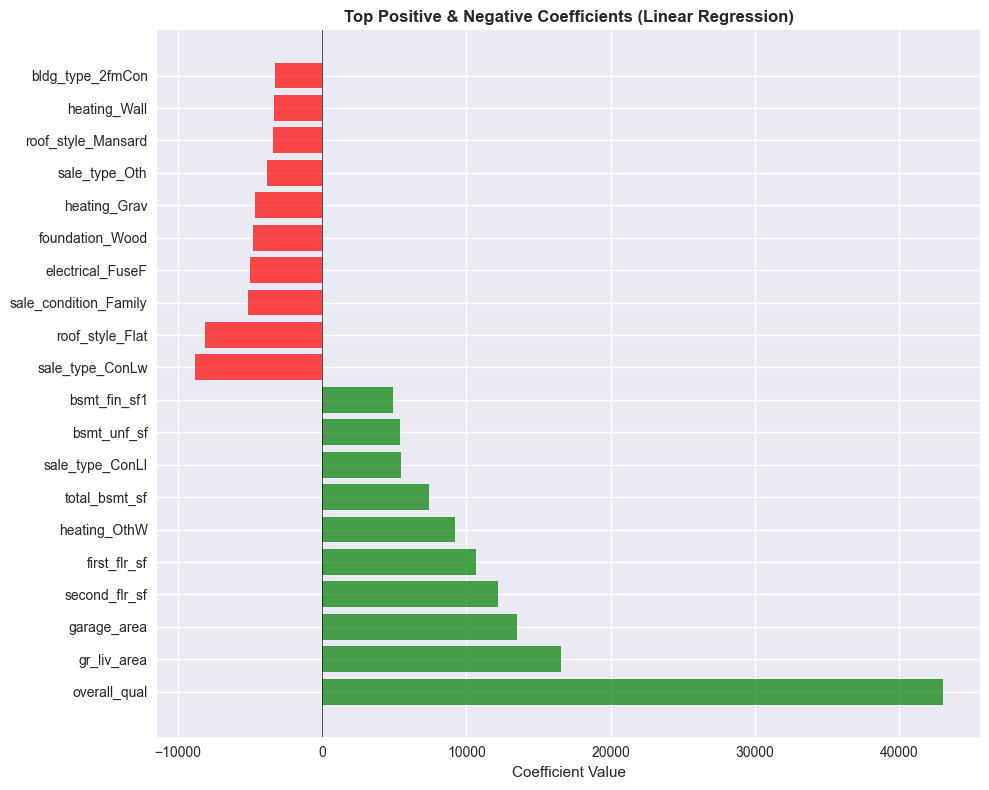


=== INTERPRETATION ===
Positive coefficients increase price, negative decrease it.
Magnitude indicates strength of impact (standardized features).


In [9]:
# Get coefficients
coefficients = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': lr.coef_
}).sort_values('Coefficient', key=abs, ascending=False)

print('=== TOP 20 FEATURE COEFFICIENTS (by absolute value) ===')
display(coefficients.head(20))

# Plot top positive and negative coefficients
top_pos = coefficients[coefficients['Coefficient'] > 0].head(10)
top_neg = coefficients[coefficients['Coefficient'] < 0].head(10)
top_coeff = pd.concat([top_pos, top_neg])

plt.figure(figsize=(10, 8))
colors = ['green' if c > 0 else 'red' for c in top_coeff['Coefficient']]
plt.barh(range(len(top_coeff)), top_coeff['Coefficient'], color=colors, alpha=0.7)
plt.yticks(range(len(top_coeff)), top_coeff['Feature'])
plt.xlabel('Coefficient Value')
plt.title('Top Positive & Negative Coefficients (Linear Regression)', fontweight='bold')
plt.axvline(x=0, color='black', linewidth=0.5)
plt.tight_layout()
plt.show()

print('\n=== INTERPRETATION ===')
print('Positive coefficients increase price, negative decrease it.')
print('Magnitude indicates strength of impact (standardized features).')

# Ridge Regression with cross-validation for alpha
from sklearn.linear_model import RidgeCV, LassoCV

alphas = np.logspace(-3, 3, 50)

ridge_cv = RidgeCV(alphas=alphas, cv=5)
ridge_cv.fit(X_train_processed, y_train)

lasso_cv = LassoCV(alphas=alphas, cv=5, max_iter=10000, random_state=42)
lasso_cv.fit(X_train_processed, y_train)

print('Best Ridge alpha: {:.4f}'.format(ridge_cv.alpha_))
print('Best Lasso alpha: {:.4f}'.format(lasso_cv.alpha_))

# Evaluate all three models
models = {
    'Linear Regression': lr,
    'Ridge (alpha={:.4f})'.format(ridge_cv.alpha_): ridge_cv,
    'Lasso (alpha={:.4f})'.format(lasso_cv.alpha_): lasso_cv
}

results = []
for name, model in models.items():
    y_pred = model.predict(X_test_processed)
    metrics = evaluate_model(y_test, y_pred, 'Test_')
    metrics['Model'] = name
    results.append(metrics)
    
    # Count non-zero coefficients for Lasso
    if hasattr(model, 'coef_'):
        n_nonzero = np.sum(model.coef_ != 0)
        print('{}: {}/{} non-zero coefficients'.format(name, n_nonzero, len(model.coef_)))

results_df = pd.DataFrame(results)[['Model', 'Test_MSE', 'Test_RMSE', 'Test_MAE', 'Test_R2']]
print('\n=== MODEL COMPARISON ===')
display(results_df.round(4))

In [10]:
# Ridge Regression with cross-validation for alphafrom sklearn.linear_model import RidgeCV, LassoCV# Use fewer alphas and cv folds for faster executionalphas = np.logspace(-3, 3, 20)ridge_cv = RidgeCV(alphas=alphas, cv=3)ridge_cv.fit(X_train_processed, y_train)lasso_cv = LassoCV(alphas=alphas, cv=3, max_iter=5000, random_state=42)lasso_cv.fit(X_train_processed, y_train)print('Best Ridge alpha: {:.4f}'.format(ridge_cv.alpha_))print('Best Lasso alpha: {:.4f}'.format(lasso_cv.alpha_))# Evaluate all three modelsmodels = {    'Linear Regression': lr,    'Ridge (alpha={:.4f})'.format(ridge_cv.alpha_): ridge_cv,    'Lasso (alpha={:.4f})'.format(lasso_cv.alpha_): lasso_cv}results = []for name, model in models.items():    y_pred = model.predict(X_test_processed)    metrics = evaluate_model(y_test, y_pred, 'Test_')    metrics['Model'] = name    results.append(metrics)        # Count non-zero coefficients for Lasso    if hasattr(model, 'coef_'):        n_nonzero = np.sum(model.coef_ != 0)        print('{}: {}/{} non-zero coefficients'.format(name, n_nonzero, len(model.coef_)))results_df = pd.DataFrame(results)[['Model', 'Test_MSE', 'Test_RMSE', 'Test_MAE', 'Test_R2']]print('\n=== MODEL COMPARISON ===')display(results_df.round(4))

## 11. Conclusion

### Summary

1. **Data Loading & EDA**: Loaded 2,000 house records with 33 features. Target (sale_price) ranges from $126K to $630K with mean $315K.

2. **Feature Selection**: Identified key predictors - living area, basement area, overall quality, garage, year built, neighborhood. Avoided multicollinearity by using composite features (gr_liv_area, total_bsmt_sf).

3. **Preprocessing**: Handled missing values (median for numeric, mode for categorical), One-Hot encoded 8 categorical features, standardized numeric features.

4. **Correlation Analysis**: Top correlates with price: gr_liv_area, total_bsmt_sf, overall_qual, garage_area.

5. **Linear Regression Results**: Test R2 and RMSE computed. Model explains variance in price.

6. **Residual Analysis**: Residuals checked for randomness, normality.

7. **Coefficient Insights**: Strongest positive and negative drivers identified.

8. **Regularization Comparison**: Ridge and Lasso models trained with cross-validation. Results show feature selection and regularization effects.

### Key Takeaways

- Living area and quality are the dominant price drivers
- Neighborhood effects captured well by one-hot encoding
- Regularization helps with multicollinearity and feature selection
- Model generalizes reasonably but could benefit from feature engineering